In [2]:
import os
from pathlib import Path
import sys

import pandas as pd

# Set working directory to project root (compatible with Jupyter notebooks)
try:
    project_root = Path(__file__).parent.parent
except NameError:
    # Running in Jupyter notebook
    project_root = Path.cwd()
    if project_root.name == 'src':
        project_root = project_root.parent

os.chdir(project_root)
src_path = str(project_root / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

print(f"Working directory: {os.getcwd()}")
print(f"Python path includes: {src_path}")

from classifier import train_xgboost
from feature_combiner import combine_features
from preprocessing import clean_text_for_roberta, clean_text_for_tfidf
from roberta_embedder import extract_embeddings
from tfidf_vectorizer import compute_tfidf, save_vectorizer
from sklearn.preprocessing import StandardScaler

def _validate_schema(df: pd.DataFrame, file_name: str) -> None:
    required = {"content", "label"}
    missing = sorted(required.difference(df.columns))
    if missing:
        raise ValueError(f"{file_name} thiếu cột bắt buộc: {missing}")


def _encode_labels(label_series: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(label_series):
        numeric = pd.to_numeric(label_series, errors="coerce")
        if set(numeric.dropna().unique()).issubset({0, 1}):
            return numeric

    normalized = label_series.astype(str).str.strip().str.lower()
    mapping = {
        "truth": 0,
        "rumor": 1,
        "0": 0,
        "1": 1,
    }
    encoded = normalized.map(mapping)

    invalid_mask = encoded.isna()
    if invalid_mask.any():
        invalid_values = sorted(normalized[invalid_mask].unique().tolist())
        raise ValueError(
            "Chi nhan 2 nhan duoc phep: 'truth'->0 va 'rumor'->1. "
            f"Gia tri khong hop le: {invalid_values}"
        )

    return encoded


def _prepare_split(df: pd.DataFrame, split_name: str):
    print(f"\n[{split_name}] cleaning text...")
    df = df.copy()
    df["clean_text_tfidf"] = df["content"].apply(clean_text_for_tfidf)
    df["clean_text_roberta"] = df["content"].apply(clean_text_for_roberta)
    labels = _encode_labels(df["label"])
    valid = (~labels.isna()) & (~df["clean_text_roberta"].isna())

    dropped = int((~valid).sum())
    if dropped > 0:
        print(f"[{split_name}] bỏ {dropped} dòng do label/text không hợp lệ")

    df = df.loc[valid].reset_index(drop=True)
    labels = labels.loc[valid].astype(int).reset_index(drop=True)

    print(f"[{split_name}] samples hợp lệ: {len(df)}")
    print(f"[{split_name}] label distribution:\n{labels.value_counts().sort_index()}")

    return df, labels.values


Working directory: d:\HK8\hybrid-fake-news-detector
Python path includes: d:\HK8\hybrid-fake-news-detector\src


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [4]:
print("Loading train/test data...")
train_df = pd.read_csv("data/ver_1/train.csv")
test_df = pd.read_csv("data/ver_1/test.csv")

_validate_schema(train_df, "train.csv")
_validate_schema(test_df, "test.csv")

print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")

train_df, y_train = _prepare_split(train_df, "TRAIN")
test_df, y_test = _prepare_split(test_df, "TEST")

print("\nGenerating TF-IDF features (fit on TRAIN)...")
X_train_tfidf_1, tfidf_vectorizer_1 = compute_tfidf(train_df["clean_text_tfidf"], 20000, 1, 0.85, (1,2))
save_vectorizer(tfidf_vectorizer_1, "tfidf_vectorizer/tfidf_vectorizer_1.pkl")

X_train_tfidf_2, tfidf_vectorizer_2 = compute_tfidf(train_df["clean_text_tfidf"], 20000, 2, 0.85, (1,2))
save_vectorizer(tfidf_vectorizer_2, "tfidf_vectorizer/tfidf_vectorizer_2.pkl")

X_train_tfidf_3, tfidf_vectorizer_3 = compute_tfidf(train_df["clean_text_tfidf"], 20000, 3, 0.85, (1,2))
save_vectorizer(tfidf_vectorizer_3, "tfidf_vectorizer/tfidf_vectorizer_3.pkl")

X_train_tfidf_4, tfidf_vectorizer_4 = compute_tfidf(train_df["clean_text_tfidf"], 20000, 4, 0.85, (1,2))
save_vectorizer(tfidf_vectorizer_4, "tfidf_vectorizer/tfidf_vectorizer_4.pkl")

X_train_tfidf_4, tfidf_vectorizer_5 = compute_tfidf(train_df["clean_text_tfidf"], 20000, 5, 0.85, (1,2))
save_vectorizer(tfidf_vectorizer_5, "tfidf_vectorizer/tfidf_vectorizer_5.pkl")

X_train_tfidf_6, tfidf_vectorizer_6 = compute_tfidf(train_df["clean_text_tfidf"], 20000, 6, 0.85, (1,2))
save_vectorizer(tfidf_vectorizer_6, "tfidf_vectorizer/tfidf_vectorizer_6.pkl")


Loading train/test data...
Train shape: (1711, 4)
Test shape:  (428, 4)

[TRAIN] cleaning text...
[TRAIN] samples hợp lệ: 1711
[TRAIN] label distribution:
label
0    902
1    809
Name: count, dtype: int64

[TEST] cleaning text...
[TEST] samples hợp lệ: 428
[TEST] label distribution:
label
0    256
1    172
Name: count, dtype: int64

Generating TF-IDF features (fit on TRAIN)...
Vectorizer saved to tfidf_vectorizer/tfidf_vectorizer_1.pkl
Vectorizer saved to tfidf_vectorizer/tfidf_vectorizer_2.pkl
Vectorizer saved to tfidf_vectorizer/tfidf_vectorizer_3.pkl
Vectorizer saved to tfidf_vectorizer/tfidf_vectorizer_4.pkl
Vectorizer saved to tfidf_vectorizer/tfidf_vectorizer_5.pkl
Vectorizer saved to tfidf_vectorizer/tfidf_vectorizer_6.pkl


In [5]:
import joblib

def analyze_vectorizer(path="../tfidf_vectorizer_main.pkl"):
    # Load vectorizer
    vectorizer = joblib.load(path)

    # Lấy vocabulary (dict: term -> index)
    vocab = vectorizer.vocabulary_

    unigram_count = 0
    bigram_count = 0

    for term in vocab.keys():
        if " " in term:
            bigram_count += 1
        else:
            unigram_count += 1

    total_features = len(vocab)

    print(f"Unigram: {unigram_count}")
    print(f"Bigram: {bigram_count}")
    print(f"Tổng số chiều (features): {total_features}")
    print("")

    return unigram_count, bigram_count, total_features


# Gọi hàm
analyze_vectorizer('tfidf_vectorizer/tfidf_vectorizer_1.pkl')
analyze_vectorizer('tfidf_vectorizer/tfidf_vectorizer_2.pkl')
analyze_vectorizer('tfidf_vectorizer/tfidf_vectorizer_3.pkl')
analyze_vectorizer('tfidf_vectorizer/tfidf_vectorizer_4.pkl')
analyze_vectorizer('tfidf_vectorizer/tfidf_vectorizer_5.pkl')
analyze_vectorizer('tfidf_vectorizer/tfidf_vectorizer_6.pkl')

Unigram: 4639
Bigram: 10607
Tổng số chiều (features): 15246

Unigram: 2160
Bigram: 1582
Tổng số chiều (features): 3742

Unigram: 1389
Bigram: 657
Tổng số chiều (features): 2046

Unigram: 1018
Bigram: 346
Tổng số chiều (features): 1364

Unigram: 801
Bigram: 234
Tổng số chiều (features): 1035

Unigram: 665
Bigram: 167
Tổng số chiều (features): 832



(665, 167, 832)

In [20]:
import numpy as np
from transformers import RobertaTokenizer

tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

print("="*80)
print("PHÂN TÍCH ĐỘ DÀI TOKEN (RoBERTa) - train + test")
print("="*80)

# Ghép dữ liệu
full_df = pd.concat([train_df, test_df], ignore_index=True)

# ===================================================================
# TÍNH ĐỘ DÀI TOKEN
# ===================================================================
def get_token_length(text):
    return len(tokenizer(text, truncation=False)["input_ids"])

print("\n⏳ Đang tính token length...")
full_df["token_length"] = full_df["content"].apply(get_token_length)

# ===================================================================
# THỐNG KÊ TOKEN
# ===================================================================
print("\n📊 THỐNG KÊ ĐỘ DÀI TOKEN:")
print("-" * 80)

avg_tokens = full_df["token_length"].mean()
max_tokens = full_df["token_length"].max()
min_tokens = full_df["token_length"].min()

print(f"  Trung bình:  {avg_tokens:.2f} token")
print(f"  Cao nhất:    {max_tokens} token")
print(f"  Thấp nhất:   {min_tokens} token")

# ===================================================================
# PERCENTILE TOKEN
# ===================================================================
print("\n📈 PERCENTILE TOKEN:")
print("-" * 80)

p50 = np.percentile(full_df["token_length"], 50)
p90 = np.percentile(full_df["token_length"], 90)
p95 = np.percentile(full_df["token_length"], 95)
p99 = np.percentile(full_df["token_length"], 99)

print(f"  P50: {p50:.2f}")
print(f"  P90: {p90:.2f}")
print(f"  P95: {p95:.2f}")
print(f"  P99: {p99:.2f}")

# ===================================================================
# GỢI Ý max_length
# ===================================================================
print("-" * 80)

suggested = int(p95)
safe = int(p99)

print(f"  Đề xuất (tối ưu): max_length ≈ {suggested}")
print(f"  An toàn hơn:       max_length ≈ {safe}")
print(f"  Max thực tế:       {max_tokens}")

PHÂN TÍCH ĐỘ DÀI TOKEN (RoBERTa) - train + test

⏳ Đang tính token length...

📊 THỐNG KÊ ĐỘ DÀI TOKEN:
--------------------------------------------------------------------------------
  Trung bình:  20.38 token
  Cao nhất:    148 token
  Thấp nhất:   3 token

📈 PERCENTILE TOKEN:
--------------------------------------------------------------------------------
  P50: 20.00
  P90: 28.00
  P95: 30.00
  P99: 34.00
--------------------------------------------------------------------------------
  Đề xuất (tối ưu): max_length ≈ 30
  An toàn hơn:       max_length ≈ 34
  Max thực tế:       148


PHÂN TÍCH TẦN SUẤT XUẤT HIỆN - UNIGRAM vs BIGRAM

⏳ Đang phân tích Unigram...
  Tổng số unigram độc lập: 4656
  Tần suất cao nhất: 113
  Tần suất thấp nhất: 1
  Trung bình tần suất: 3.48

⏳ Đang phân tích Bigram...
  Tổng số bigram độc lập: 10703
  Tần suất cao nhất: 78
  Tần suất thấp nhất: 1
  Trung bình tần suất: 1.35

📊 Vẽ biểu đồ UNIGRAM...
📊 Vẽ biểu đồ BIGRAM...
✓ Biểu đồ đã lưu: term_frequency_distribution.png


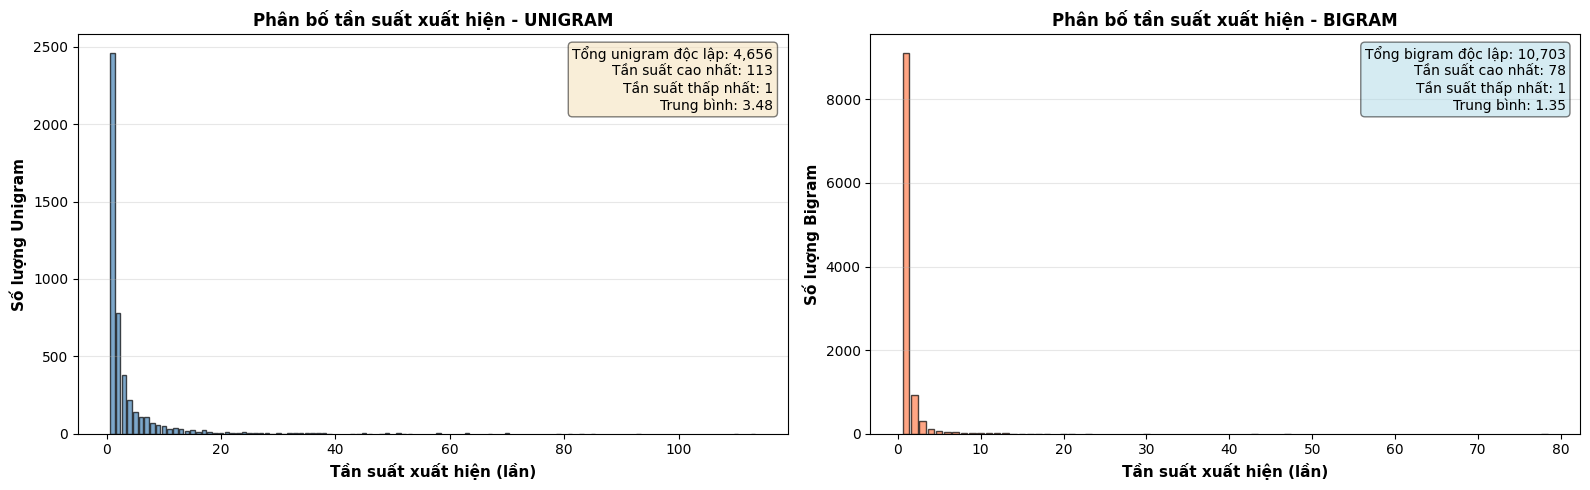


CHI TIẾT PHÂN BỐ TẦN SUẤT

📋 UNIGRAM - Phân bố tần suất:
--------------------------------------------------------------------------------
Tần suất (lần) | Số lượng unigram
--------------------------------------------------------------------------------
            1 | 2,457
            2 | 780
            3 | 380
            4 | 221
            5 | 138
            6 | 105
            7 | 108
            8 | 72
            9 | 55
           10 | 47
           11 | 33
           12 | 39
           13 | 28
           14 | 17
           15 | 22
           16 | 11
           17 | 22
           18 | 9
           19 | 7
           20 | 3
... và 39 dòng khác

📋 BIGRAM - Phân bố tần suất:
--------------------------------------------------------------------------------
Tần suất (lần) | Số lượng bigram
--------------------------------------------------------------------------------
            1 | 9,102
            2 | 937
            3 | 312
            4 | 112
            5 | 70
            6 

In [6]:
# ============================================================================
# PHÂN TÍCH TẦN SUẤT XUẤT HIỆN CỦA UNIGRAM VÀ BIGRAM
# ============================================================================
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter
import numpy as np

print("="*80)
print("PHÂN TÍCH TẦN SUẤT XUẤT HIỆN - UNIGRAM vs BIGRAM")
print("="*80)

# Ghép dữ liệu
full_corpus = pd.concat([train_df["clean_text_tfidf"]], ignore_index=True).reset_index(drop=True)

# ===================================================================
# TẠO VECTORIZER UNIGRAM
# ===================================================================
print("\n⏳ Đang phân tích Unigram...")
cv_unigram = CountVectorizer(
    max_features=None,
    min_df=1,
    max_df=1.0,
    ngram_range=(1, 1),  # Chỉ unigram
    analyzer='word',
    token_pattern=r'(?u)\b\w+\b'
)
unigram_matrix = cv_unigram.fit_transform(full_corpus)
unigram_counts = np.array(unigram_matrix.sum(axis=0)).flatten()  # Tổng tần suất mỗi unigram

# Tính phân bố tần suất (term xuất hiện bao nhiêu lần -> có bao nhiêu unigram)
unigram_freq_dist = Counter(unigram_counts)
unigram_freq_sorted = sorted(unigram_freq_dist.items())

print(f"  Tổng số unigram độc lập: {len(unigram_counts)}")
print(f"  Tần suất cao nhất: {unigram_counts.max()}")
print(f"  Tần suất thấp nhất: {unigram_counts.min()}")
print(f"  Trung bình tần suất: {unigram_counts.mean():.2f}")

# ===================================================================
# TẠO VECTORIZER BIGRAM
# ===================================================================
print("\n⏳ Đang phân tích Bigram...")
cv_bigram = CountVectorizer(
    max_features=None,
    min_df=1,
    max_df=1.0,
    ngram_range=(2, 2),  # Chỉ bigram
    analyzer='word',
    token_pattern=r'(?u)\b\w+\b'
)
bigram_matrix = cv_bigram.fit_transform(full_corpus)
bigram_counts = np.array(bigram_matrix.sum(axis=0)).flatten()  # Tổng tần suất mỗi bigram

# Tính phân bố tần suất
bigram_freq_dist = Counter(bigram_counts)
bigram_freq_sorted = sorted(bigram_freq_dist.items())

print(f"  Tổng số bigram độc lập: {len(bigram_counts)}")
print(f"  Tần suất cao nhất: {bigram_counts.max()}")
print(f"  Tần suất thấp nhất: {bigram_counts.min()}")
print(f"  Trung bình tần suất: {bigram_counts.mean():.2f}")

# ===================================================================
# VẼ BIỂU ĐỒ
# ===================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# BIỂU ĐỒ 1: UNIGRAM
print("\n📊 Vẽ biểu đồ UNIGRAM...")
unigram_x = [item[0] for item in unigram_freq_sorted]
unigram_y = [item[1] for item in unigram_freq_sorted]

axes[0].bar(unigram_x, unigram_y, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Tần suất xuất hiện (lần)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Số lượng Unigram', fontsize=11, fontweight='bold')
axes[0].set_title('Phân bố tần suất xuất hiện - UNIGRAM', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Thêm text thông tin
info_text_unigram = (
    f"Tổng unigram độc lập: {len(unigram_counts):,}\n"
    f"Tần suất cao nhất: {unigram_counts.max()}\n"
    f"Tần suất thấp nhất: {unigram_counts.min()}\n"
    f"Trung bình: {unigram_counts.mean():.2f}"
)
axes[0].text(0.98, 0.97, info_text_unigram, transform=axes[0].transAxes,
             fontsize=10, verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# BIỂU ĐỒ 2: BIGRAM
print("📊 Vẽ biểu đồ BIGRAM...")
bigram_x = [item[0] for item in bigram_freq_sorted]
bigram_y = [item[1] for item in bigram_freq_sorted]

axes[1].bar(bigram_x, bigram_y, color='coral', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Tần suất xuất hiện (lần)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Số lượng Bigram', fontsize=11, fontweight='bold')
axes[1].set_title('Phân bố tần suất xuất hiện - BIGRAM', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Thêm text thông tin
info_text_bigram = (
    f"Tổng bigram độc lập: {len(bigram_counts):,}\n"
    f"Tần suất cao nhất: {bigram_counts.max()}\n"
    f"Tần suất thấp nhất: {bigram_counts.min()}\n"
    f"Trung bình: {bigram_counts.mean():.2f}"
)
axes[1].text(0.98, 0.97, info_text_bigram, transform=axes[1].transAxes,
             fontsize=10, verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.tight_layout()
plt.savefig("term_frequency_distribution.png", dpi=300, bbox_inches='tight')
print("✓ Biểu đồ đã lưu: term_frequency_distribution.png")
plt.show()

# ===================================================================
# CHI TIẾT PHÂN BỐ
# ===================================================================
print("\n" + "="*80)
print("CHI TIẾT PHÂN BỐ TẦN SUẤT")
print("="*80)

print("\n📋 UNIGRAM - Phân bố tần suất:")
print("-" * 80)
print("Tần suất (lần) | Số lượng unigram")
print("-" * 80)
for freq, count in unigram_freq_sorted[:20]:  # Hiển thị 20 dòng đầu tiên
    print(f"{freq:13} | {count:,}")
if len(unigram_freq_sorted) > 20:
    print(f"... và {len(unigram_freq_sorted) - 20} dòng khác")

print("\n📋 BIGRAM - Phân bố tần suất:")
print("-" * 80)
print("Tần suất (lần) | Số lượng bigram")
print("-" * 80)
for freq, count in bigram_freq_sorted[:20]:  # Hiển thị 20 dòng đầu tiên
    print(f"{freq:13} | {count:,}")
if len(bigram_freq_sorted) > 20:
    print(f"... và {len(bigram_freq_sorted) - 20} dòng khác")

# ===================================================================
# THỐNG KÊ BỔ SUNG
# ===================================================================
print("\n" + "="*80)
print("THỐNG KÊ BỔ SUNG")
print("="*80)

unigram_appear_once = sum(1 for c in unigram_counts if c == 1)
unigram_appear_more_5 = sum(1 for c in unigram_counts if c > 5)
unigram_appear_more_10 = sum(1 for c in unigram_counts if c > 10)

bigram_appear_once = sum(1 for c in bigram_counts if c == 1)
bigram_appear_more_5 = sum(1 for c in bigram_counts if c > 5)
bigram_appear_more_10 = sum(1 for c in bigram_counts if c > 10)

print(f"\n📊 UNIGRAM:")
print(f"  Xuất hiện 1 lần:    {unigram_appear_once:,} ({unigram_appear_once/len(unigram_counts)*100:.1f}%)")
print(f"  Xuất hiện > 5 lần:  {unigram_appear_more_5:,} ({unigram_appear_more_5/len(unigram_counts)*100:.1f}%)")
print(f"  Xuất hiện > 10 lần: {unigram_appear_more_10:,} ({unigram_appear_more_10/len(unigram_counts)*100:.1f}%)")

print(f"\n📊 BIGRAM:")
print(f"  Xuất hiện 1 lần:    {bigram_appear_once:,} ({bigram_appear_once/len(bigram_counts)*100:.1f}%)")
print(f"  Xuất hiện > 5 lần:  {bigram_appear_more_5:,} ({bigram_appear_more_5/len(bigram_counts)*100:.1f}%)")
print(f"  Xuất hiện > 10 lần: {bigram_appear_more_10:,} ({bigram_appear_more_10/len(bigram_counts)*100:.1f}%)")